In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# تحميل ملف البيانات
file_name = r'C:\Users\Mariam\Downloads\e4sZehELiQN8DgOIUEFVhQPAWSUu8y3g.xlsx'
df = pd.read_excel(file_name)

# عرض أول 5 صفوف للتأكد من البيانات
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Age,Outcome
0,6,148,72,35,0,33.6,50,1
1,1,85,66,29,0,26.6,31,0
2,8,183,64,0,0,23.3,32,1
3,1,89,66,23,94,28.1,21,0
4,0,137,40,35,168,43.1,33,1


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Pregnancies    150 non-null    int64  
 1   Glucose        150 non-null    int64  
 2   BloodPressure  150 non-null    int64  
 3   SkinThickness  150 non-null    int64  
 4   Insulin        150 non-null    int64  
 5   BMI            150 non-null    float64
 6   Age            150 non-null    int64  
 7   Outcome        150 non-null    int64  
dtypes: float64(1), int64(7)
memory usage: 9.5 KB


In [33]:
#لا توجد قيم null
df.isnull().sum()

Pregnancies      0
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
Age              0
Outcome          0
dtype: int64

In [5]:
# حساب المتوسط، الانحراف المعياري، القيم الصغرى والعظمى
summary_stats = df.describe().T
summary_stats['median'] = df.median() 

print("--- الإحصائيات الأساسية للمتغيرات ---")
display(summary_stats)

--- الإحصائيات الأساسية للمتغيرات ---


,count,mean,std,min,25%,50%,75%,max,median
Pregnancies,150.0,5.466667,3.742853,0.0,1.0,5.50,8.0,13.0,5.50
Glucose,150.0,130.066667,32.344552,78.0,107.0,122.00,147.0,197.0,122.00
BloodPressure,150.0,68.533333,23.595776,0.0,66.0,73.00,84.0,96.0,73.00
SkinThickness,150.0,17.500000,16.770760,0.0,0.0,19.00,33.0,47.0,19.00
Insulin,150.0,102.300000,179.718861,0.0,0.0,0.00,140.0,846.0,0.00
BMI,150.0,31.636667,8.549794,0.0,27.1,31.05,37.6,45.8,31.05
Age,150.0,37.933333,11.547780,21.0,30.0,33.00,50.0,59.0,33.00
Outcome,150.0,0.566667,0.497196,0.0,0.0,1.00,1.0,1.0,1.00


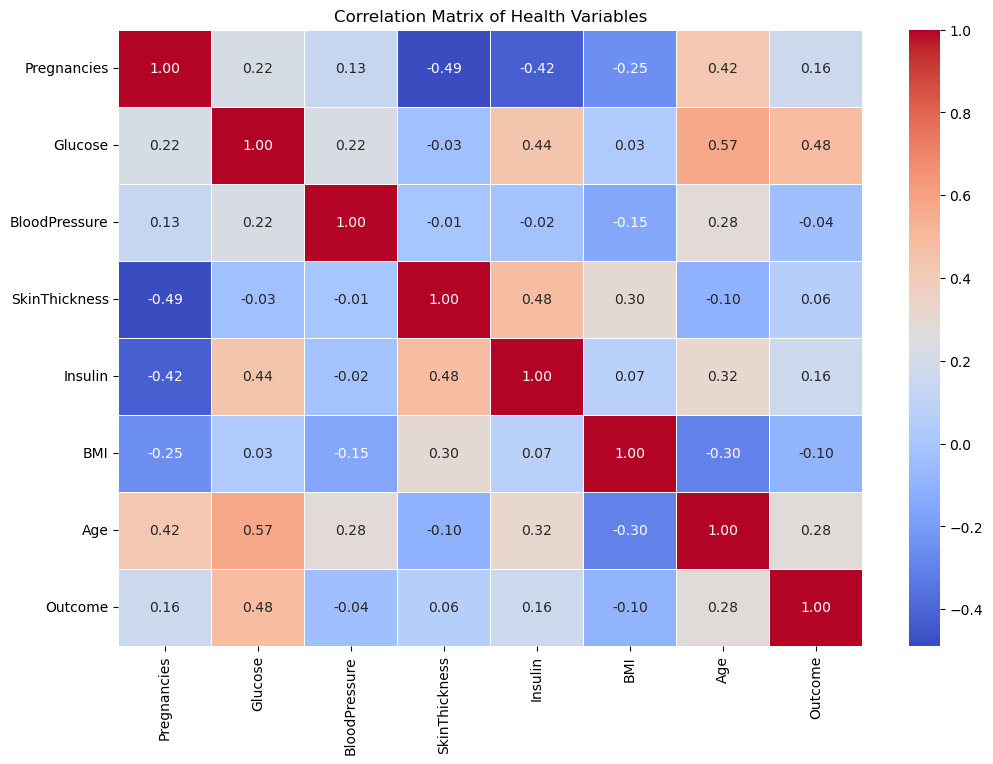

In [9]:
# Create a correlation matrix to find relationships between variables
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()

# Visualize the correlations using a heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Health Variables')
plt.show()

## Age and BMI Relationship

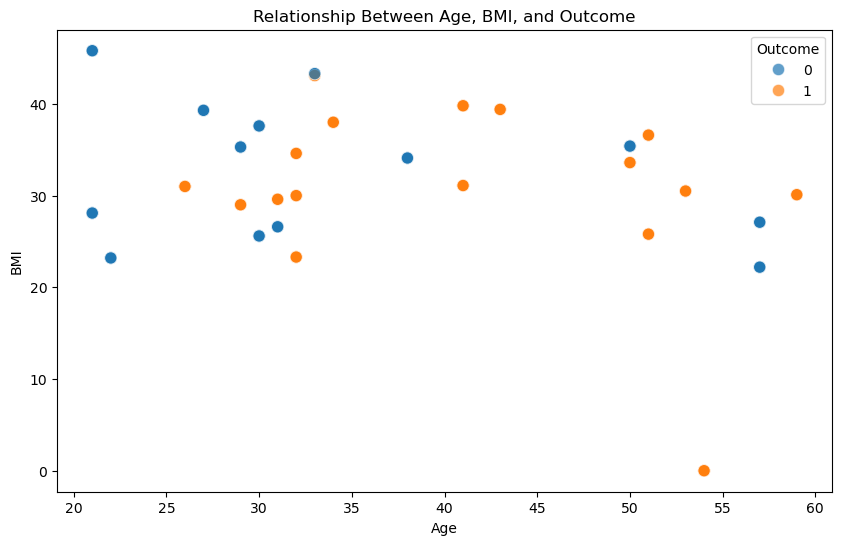

In [15]:
# Scatter plot to see how Age and BMI relate to the Outcome
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='BMI', hue='Outcome', alpha=0.7, s=80)

plt.title('Relationship Between Age, BMI, and Outcome')
plt.xlabel('Age')
plt.ylabel('BMI')
plt.legend(title='Outcome')
plt.show()

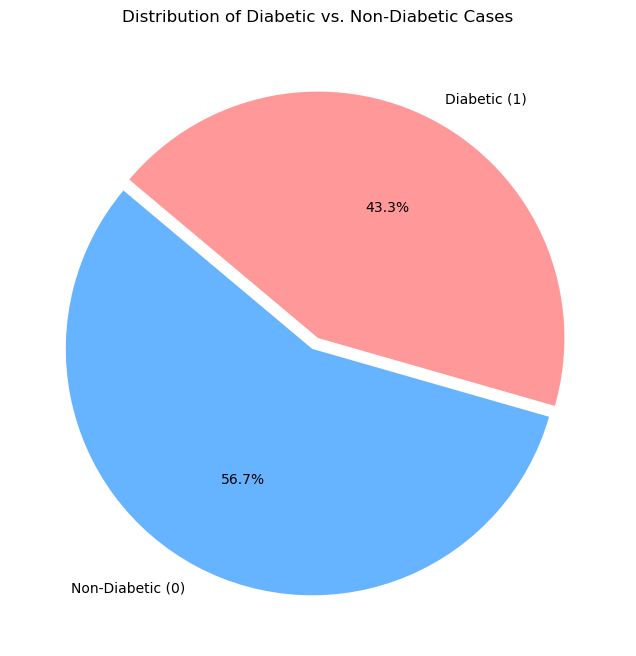

Outcome
1    85
0    65
Name: count, dtype: int64


In [24]:
import matplotlib.pyplot as plt
import pandas as pd
# Calculate counts for the pie chart
outcome_counts = df['Outcome'].value_counts()
labels = ['Non-Diabetic (0)', 'Diabetic (1)']
colors = ['#66b3ff', '#ff9999']

# Create the Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(outcome_counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, explode=(0.05, 0))
plt.title('Distribution of Diabetic vs. Non-Diabetic Cases')
plt.savefig('outcome_pie_chart.png')
plt.show()

print(outcome_counts)

## Key Statistics
Diabetic (Outcome 1): 85 individuals (43.3%)

Non-Diabetic (Outcome 0): 65 individuals (56.7%)

## Summary of the Analysis based on the file:
### Glucose is the strongest predictor:
There is a clear statistical gap where individuals with higher glucose levels are significantly more likely to have a positive Outcome.

### *Correlation*: 
There is a notable positive correlation between Age and Glucose (0.57), suggesting that as age increases, glucose levels in this sample tend to rise.

### Data Integrity:
Some columns (like BMI and BloodPressure) contain "0" values, which are likely missing data points and should be handled before building any machine learning models.

### Outcome Distribution:
The mean for Outcome is 0.57, which tells us that approximately 57% of the individuals in this sample are classified as positive (1).

### Glucose Trends:
The average Glucose level is 130.07 mg/dL, with a significant range between 78 and 197. As noted earlier, this is the most critical variable for distinguishing between outcomes.

### Missing Data Indicators: 
The presence of 0.0 as a minimum value for BloodPressure and BMI is physiologically unlikely and suggests these are placeholders for missing data.

### High Variability: 
Insulin levels show the highest volatility (Standard Deviation of 179.72), indicating extreme differences in how individuals' bodies are processing sugar or responding to treatment in this group.